In [16]:
import gc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

## Pipeline Testing

In [17]:
# --- Data Configuration ---
NB_BARS_PER_DAY_SYMBOL = 10000
WINDOW_LENGTH = 150
TARGET_WINDOW_LENGTH =50
BASE_OUTPUT_DIR = '/mnt/storage_1_10T/citibank/data/processed_data_volume_bars'
PARAMS_SUBDIR = f"volbars_{NB_BARS_PER_DAY_SYMBOL}_in{WINDOW_LENGTH}_tgt{TARGET_WINDOW_LENGTH}"
PROCESSED_DATA_DIR = os.path.join(BASE_OUTPUT_DIR, PARAMS_SUBDIR)

# Select a day to test
TEST_DAY = '20250212' 
# --------------------------------------------------------------------

print(f"Testing data from directory: {PROCESSED_DATA_DIR}")
print(f"Testing day: {TEST_DAY}")

Testing data from directory: /mnt/storage_1_10T/citibank/data/processed_data_volume_bars/volbars_10000_in150_tgt50
Testing day: 20250212


In [18]:
day_data_path = os.path.join(PROCESSED_DATA_DIR, TEST_DAY)

x_windows_path = os.path.join(day_data_path, f'X_windows_in{WINDOW_LENGTH}_tgt{TARGET_WINDOW_LENGTH}.npy')
target_windows_path = os.path.join(day_data_path, f'target_windows_in{WINDOW_LENGTH}_tgt{TARGET_WINDOW_LENGTH}.npy')
window_info_path = os.path.join(day_data_path, f'window_info_in{WINDOW_LENGTH}_tgt{TARGET_WINDOW_LENGTH}.parquet')

print(f"X Windows file: {x_windows_path}")
print(f"Target Windows file: {target_windows_path}")
print(f"Window Info file: {window_info_path}")

# Check if files exist
if not os.path.exists(x_windows_path): print(f"ERROR: X Windows file not found!")
if not os.path.exists(target_windows_path): print(f"ERROR: Target Windows file not found!")
if not os.path.exists(window_info_path): print(f"ERROR: Window Info file not found!")

X Windows file: /mnt/storage_1_10T/citibank/data/processed_data_volume_bars/volbars_10000_in150_tgt50/20250212/X_windows_in150_tgt50.npy
Target Windows file: /mnt/storage_1_10T/citibank/data/processed_data_volume_bars/volbars_10000_in150_tgt50/20250212/target_windows_in150_tgt50.npy
Window Info file: /mnt/storage_1_10T/citibank/data/processed_data_volume_bars/volbars_10000_in150_tgt50/20250212/window_info_in150_tgt50.parquet


In [19]:
X_windows = np.load(x_windows_path)
target_windows = np.load(target_windows_path)
window_info = pd.read_parquet(window_info_path)
print("Data loaded successfully!")

Data loaded successfully!


In [5]:
path_features = os.path.join(day_data_path, 'features.txt')
features = pd.read_csv(path_features, sep=',')
features.head()
features.shape
features.columns

Index(['wmp_mean\nwmp_first\nwmp_last\nwmp_min\nwmp_max\nwmp_median\nwmp_std\nL1_bid_price_mean\nL1_bid_price_sum\nL1_bid_price_min\nL1_bid_price_max\nL1_bid_price_std\nL1_bid_price_median\nL1_bid_size_mean\nL1_bid_size_sum\nL1_bid_size_min\nL1_bid_size_max\nL1_bid_size_std\nL1_bid_size_median\nL1_bid_no_mean\nL1_bid_no_sum\nL1_bid_no_min\nL1_bid_no_max\nL1_bid_no_std\nL1_bid_no_median\nL1_ask_price_mean\nL1_ask_price_sum\nL1_ask_price_min\nL1_ask_price_max\nL1_ask_price_std\nL1_ask_price_median\nL1_ask_size_mean\nL1_ask_size_sum\nL1_ask_size_min\nL1_ask_size_max\nL1_ask_size_std\nL1_ask_size_median\nL1_ask_no_mean\nL1_ask_no_sum\nL1_ask_no_min\nL1_ask_no_max\nL1_ask_no_std\nL1_ask_no_median\nL2_bid_price_mean\nL2_bid_price_sum\nL2_bid_price_min\nL2_bid_price_max\nL2_bid_price_std\nL2_bid_price_median\nL2_bid_size_mean\nL2_bid_size_sum\nL2_bid_size_min\nL2_bid_size_max\nL2_bid_size_std\nL2_bid_size_median\nL2_bid_no_mean\nL2_bid_no_sum\nL2_bid_no_min\nL2_bid_no_max\nL2_bid_no_std\nL2_b

In [9]:
# PARAMS_SUBDIR = f"volbars_{NB_BARS_PER_DAY_SYMBOL}_in{WINDOW_LENGTH}_tgt{TARGET_WINDOW_LENGTH}_TEST"
# PROCESSED_DATA_DIR = os.path.join(BASE_OUTPUT_DIR, PARAMS_SUBDIR)

# x_windows_path1 = os.path.join(day_data_path, f'X_windows_in{WINDOW_LENGTH}_tgt{TARGET_WINDOW_LENGTH}.npy')
# target_windows_path1 = os.path.join(day_data_path, f'target_windows_in{WINDOW_LENGTH}_tgt{TARGET_WINDOW_LENGTH}.npy')
# window_info_path1 = os.path.join(day_data_path, f'window_info_in{WINDOW_LENGTH}_tgt{TARGET_WINDOW_LENGTH}.parquet')

# X_windows1 = np.load(x_windows_path1)
# target_windows1 = np.load(target_windows_path1)
# window_info1 = pd.read_parquet(window_info_path1)


# PARAMS_SUBDIR = f"volbars_{NB_BARS_PER_DAY_SYMBOL}_in{WINDOW_LENGTH}_tgt{TARGET_WINDOW_LENGTH}_TEST2"
# PROCESSED_DATA_DIR = os.path.join(BASE_OUTPUT_DIR, PARAMS_SUBDIR)

# x_windows_path2 = os.path.join(day_data_path, f'X_windows_in{WINDOW_LENGTH}_tgt{TARGET_WINDOW_LENGTH}.npy')
# target_windows_path2 = os.path.join(day_data_path, f'target_windows_in{WINDOW_LENGTH}_tgt{TARGET_WINDOW_LENGTH}.npy')
# window_info_path2 = os.path.join(day_data_path, f'window_info_in{WINDOW_LENGTH}_tgt{TARGET_WINDOW_LENGTH}.parquet')

# X_windows2 = np.load(x_windows_path2)
# target_windows2 = np.load(target_windows_path2)
# window_info2 = pd.read_parquet(window_info_path2)

# print(X_windows1.shape, X_windows2.shape)
# print(np.all(X_windows1 == X_windows2))

In [6]:
if X_windows is not None:
    print("--- X_windows Validation ---")
    print(f"Shape: {X_windows.shape}")
    print(f"Data Type: {X_windows.dtype}")
    print(f"Contains NaN: {np.isnan(X_windows).any()}")
    print(f"Contains Inf: {np.isinf(X_windows).any()}")
    num_features = X_windows.shape[2]
    print(f"Number of features per bar: {num_features}")
    
if target_windows is not None:
    print("\n--- target_windows Validation ---")
    print(f"Shape: {target_windows.shape}")
    print(f"Data Type: {target_windows.dtype}")
    print(f"Contains NaN: {np.isnan(target_windows).any()}")
    print(f"Contains Inf: {np.isinf(target_windows).any()}")
    
if window_info is not None:
    print("\n--- window_info Validation ---")
    print(f"Shape: {window_info.shape}")
    print("Info:")
    window_info.info()
    print("\nHead:")
    print(window_info.head())
    print("\nTail:")
    print(window_info.tail())
    print("\nUnique Symbols:")
    print(window_info['sym'].unique())
    print(f"\nIs 'window_end_time' sorted? {window_info['window_end_time'].is_monotonic_increasing}")
    
# Check consistency
if X_windows is not None and target_windows is not None and window_info is not None:
    print("\n--- Consistency Check ---")
    print(f"Length Match (X, target, info): {len(X_windows) == len(target_windows) == len(window_info)}") 

--- X_windows Validation ---
Shape: (55546, 150, 673)
Data Type: float32
Contains NaN: False
Contains Inf: False
Number of features per bar: 673

--- target_windows Validation ---
Shape: (55546, 50)
Data Type: float32
Contains NaN: False
Contains Inf: False

--- window_info Validation ---
Shape: (55546, 3)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55546 entries, 0 to 55545
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   window_end_time        55546 non-null  datetime64[ns]
 1   last_target_in_window  55546 non-null  float32       
 2   sym                    55546 non-null  object        
dtypes: datetime64[ns](1), float32(1), object(1)
memory usage: 1.1+ MB

Head:
                window_end_time  last_target_in_window     sym
0 2025-02-12 13:12:10.050896540             124.491577  FBONH5
1 2025-02-12 13:13:14.092082709             124.503525  FBONH5
2 2025-02-12 13:

In [7]:
mean_target = np.mean(target_windows, axis=1)
relative_mean_target = (mean_target - window_info['last_target_in_window'].values) / window_info['last_target_in_window'].values

In [8]:
relative_mean_target.min(), relative_mean_target.max()

(np.float32(-0.005162327), np.float32(0.0009228286))

<Axes: ylabel='Count'>

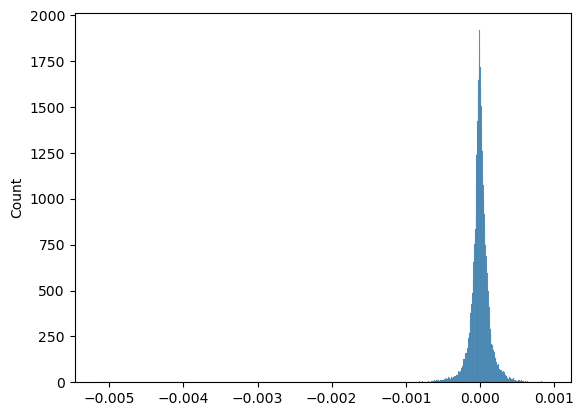

In [9]:
import seaborn as sns

sns.histplot(relative_mean_target)

In [10]:
window_info.groupby('sym').size()

sym
FBONH5      87
FBTPH5    9801
FBTSH5    2364
FGBLH5    9801
FGBMH5    9801
FGBSH5    4090
FGBXH5    9801
FOATH5    9801
dtype: int64

In [11]:
idx = 4009

X_windows[idx,-1,0], window_info['last_target_in_window'].values[idx]

(np.float32(120.05597), np.float32(120.05597))

In [12]:
X_windows.shape, window_info.shape

((55546, 150, 673), (55546, 3))

In [13]:
print(np.all(np.isclose(X_windows[:,-1,0], window_info['last_target_in_window'].values)))

num_mismatches = np.sum(~np.isclose(X_windows[:,-1,0], window_info['last_target_in_window'].values))
print(f"Number of mismatches: {num_mismatches}")

True
Number of mismatches: 0


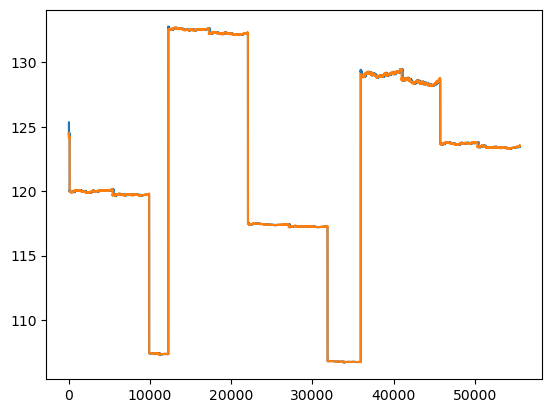

In [14]:
import matplotlib.pyplot as plt

plt.plot(X_windows[:,0,0])
plt.plot(window_info['last_target_in_window'].values)

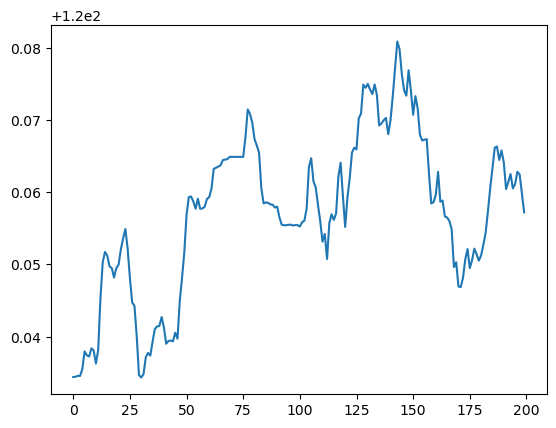

In [15]:
idx = 1000

plt.plot(np.concatenate([X_windows[idx,:,0], target_windows[idx]]))

In [20]:
X_windows[idx,-1,0]

np.float32(120.03809)

In [21]:
target_windows[idx]

array([120.03627 , 120.03815 , 120.04536 , 120.05029 , 120.05173 ,
       120.051216, 120.04974 , 120.04949 , 120.04818 , 120.049484],
      dtype=float32)

## ML Pipeline

In [2]:
# --- Data Configuration ---
NB_BARS_PER_DAY_SYMBOL = 10000
WINDOW_LENGTH = 150
TARGET_WINDOW_LENGTH = 30
BASE_OUTPUT_DIR = '/mnt/user_disk/kfeghoul/storage_1_10T/Citibank/processed_data_volume_bars'
PARAMS_SUBDIR = f"volbars_{NB_BARS_PER_DAY_SYMBOL}_in{WINDOW_LENGTH}_tgt{TARGET_WINDOW_LENGTH}"
PROCESSED_DATA_DIR = os.path.join(BASE_OUTPUT_DIR, PARAMS_SUBDIR)

TRAIN_DAYS = ['20250212', '20250213', '20250214', '20250217', '20250218', '20250219', '20250220']
TEST_DAYS = ['20250221', '20250224', '20250225']

In [3]:
all_X_windows_list = []
all_target_windows_list = []
all_window_info_list = []

for day in tqdm(TRAIN_DAYS, total=len(TRAIN_DAYS), desc="Processing data"):
    print(f"Processing training data for day: {day}")
    train_data_path = os.path.join(PROCESSED_DATA_DIR, day)
    if not os.path.exists(train_data_path):
        print(f"ERROR: Training data path not found for day: {day}")
        continue
    print(f"Training data path: {train_data_path}")

    x_windows_path = os.path.join(train_data_path, f'X_windows_in{WINDOW_LENGTH}_tgt{TARGET_WINDOW_LENGTH}.npy')
    target_windows_path = os.path.join(train_data_path, f'target_windows_in{WINDOW_LENGTH}_tgt{TARGET_WINDOW_LENGTH}.npy')
    window_info_path = os.path.join(train_data_path, f'window_info_in{WINDOW_LENGTH}_tgt{TARGET_WINDOW_LENGTH}.parquet')

    X_windows = np.load(x_windows_path)
    target_windows = np.load(target_windows_path)
    window_info = pd.read_parquet(window_info_path)

    all_X_windows_list.append(X_windows)
    all_target_windows_list.append(target_windows)
    all_window_info_list.append(window_info)

    print(f"x Windows shape: {X_windows.shape}")
    print(f"target windows shape: {target_windows.shape}")
    print(f"window info shape: {window_info.shape}")

Processing data:   0%|          | 0/7 [00:00<?, ?it/s]

Processing training data for day: 20250212
Training data path: /mnt/user_disk/kfeghoul/storage_1_10T/Citibank/processed_data_volume_bars/volbars_10000_in150_tgt30/20250212


Processing data:  14%|█▍        | 1/7 [01:13<07:19, 73.18s/it]

x Windows shape: (55706, 150, 409)
target windows shape: (55706, 30)
window info shape: (55706, 3)
Processing training data for day: 20250213
Training data path: /mnt/user_disk/kfeghoul/storage_1_10T/Citibank/processed_data_volume_bars/volbars_10000_in150_tgt30/20250213


Processing data:  29%|██▊       | 2/7 [01:59<04:47, 57.43s/it]

...

x Windows shape: (51372, 150, 409)
target windows shape: (51372, 30)
window info shape: (51372, 3)
Processing training data for day: 20250219
Training data path: /mnt/user_disk/kfeghoul/storage_1_10T/Citibank/processed_data_volume_bars/volbars_10000_in150_tgt30/20250219


Processing data:  86%|████████▌ | 6/7 [02:13<00:10, 10.93s/it]

x Windows shape: (53475, 150, 409)
target windows shape: (53475, 30)
window info shape: (53475, 3)
Processing training data for day: 20250220
Training data path: /mnt/user_disk/kfeghoul/storage_1_10T/Citibank/processed_data_volume_bars/volbars_10000_in150_tgt30/20250220


Processing data: 100%|██████████| 7/7 [02:55<00:00, 25.02s/it]

x Windows shape: (52839, 150, 409)
target windows shape: (52839, 30)
window info shape: (52839, 3)


In [4]:
X_windows = np.concatenate(all_X_windows_list, axis=0)
target_windows = np.concatenate(all_target_windows_list, axis=0)
window_info = pd.concat(all_window_info_list, ignore_index=True)

In [5]:
X_windows.shape, target_windows.shape, window_info.shape

((373487, 150, 409), (373487, 30), (373487, 3))

: 

In [ ]:
num_samples_filtered, window_len, num_original_features = X_windows.shape
new_tabular_features_list = []
new_feature_names = []

for i in tqdm(range(num_original_features), desc="  Extracting stats per feature"):
    feature_data_over_window = X_windows[:, :, i] # Shape: (num_samples_filtered, window_len)
    #original_feature_name = feature_names[i] if 'feature_names' in locals() and i < len(feature_names) else f"orig_feat_{i}"

    new_tabular_features_list.append(np.mean(feature_data_over_window, axis=1))
    #new_feature_names.append(f"{original_feature_name}_mean")

    new_tabular_features_list.append(np.std(feature_data_over_window, axis=1))
    #new_feature_names.append(f"{original_feature_name}_std")

    new_tabular_features_list.append(np.median(feature_data_over_window, axis=1))
    #new_feature_names.append(f"{original_feature_name}_median")

    new_tabular_features_list.append(np.min(feature_data_over_window, axis=1))
    #new_feature_names.append(f"{original_feature_name}_min")

    new_tabular_features_list.append(np.max(feature_data_over_window, axis=1))
    #new_feature_names.append(f"{original_feature_name}_max")

  Extracting stats per feature:  33%|███▎      | 133/409 [12:21<26:40,  5.80s/it]

In [5]:
# Stack the new features into a 2D array
X_tabular = np.column_stack(new_tabular_features_list)
X_tabular_df = pd.DataFrame(X_tabular, columns=new_feature_names)

ValueError: Shape of passed values is (52839, 2045), indices imply (52839, 0)